# SNP data and *mapper* / SNP 데이터와 *mapper*

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans Mono'
from plotly.subplots import make_subplots
from data import load_data

df = load_data()
fd = df.transpose().iloc[3:]

base_freq = np.zeros((df.shape[1]-3, 4))
for num, (name, col) in enumerate(df.iloc[:, 3:].items()):
    base_freq[num, 0] = col.str.count('A').sum()
    base_freq[num, 1] = col.str.count('C').sum()
    base_freq[num, 2] = col.str.count('G').sum()
    base_freq[num, 3] = col.str.count('T').sum()
base_freq_rel = base_freq / np.sum(base_freq, axis=1, keepdims=True)

mask_AC = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [0, 1], axis=1)
mask_CA = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [1, 0], axis=1)
mask_AG = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [0, 2], axis=1)
mask_GA = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [2, 0], axis=1)
mask_CT = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [1, 3], axis=1)
mask_TC = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [3, 1], axis=1)
mask_GT = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [2, 3], axis=1)
mask_TG = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [3, 2], axis=1)

mask_AC_CA = mask_AC | mask_CA
mask_AG_GA = mask_AG | mask_GA
mask_CT_TC = mask_CT | mask_TC
mask_GT_TG = mask_GT | mask_TG

## 샘플들(사람들)간의 거리를 측정한다

In [3]:
import itertools

dist_d = np.zeros((df.shape[0], df.shape[0]))
for i in range(df.shape[0]):
    dist_d[i] = (df.iloc[i, 3:] != df.iloc[:, 3:]).sum(axis=1)

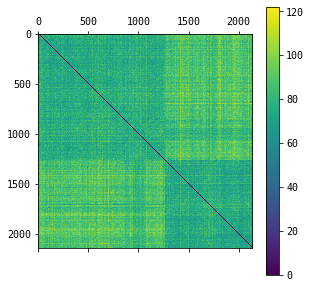

In [4]:
plt.colorbar(plt.matshow(dist_d))

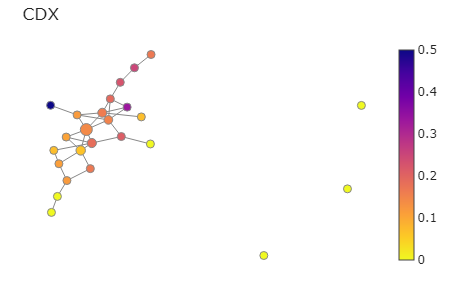

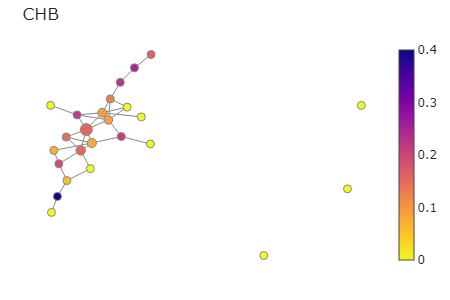

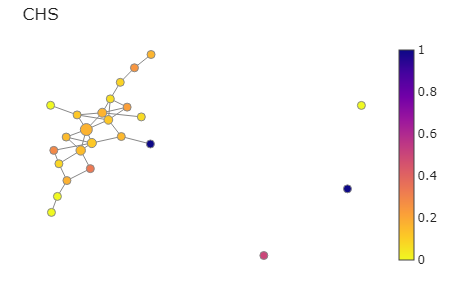

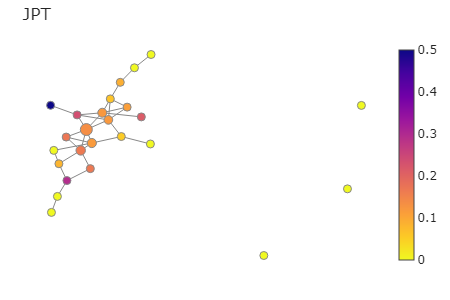

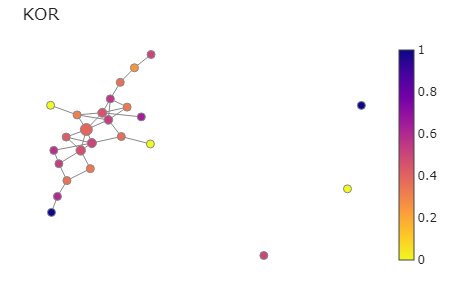

In [5]:
from gtda.mapper import CubicalCover, Projection, Eccentricity, Entropy, make_mapper_pipeline, plot_static_mapper_graph
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.pipeline import make_union
# from umap import UMAP


# umap = UMAP(random_state=42)

mask = df['Geographic region'] == 'NEA'

pipe = make_mapper_pipeline(
    filter_func=make_union(
        Eccentricity(
            exponent=2,
            metric='precomputed'
        ),
        Entropy(),
    ),
    cover=CubicalCover(n_intervals=6, overlap_frac=0.08),
    clusterer=DBSCAN(
        metric='precomputed'
    ),
)

for num, pop in enumerate(df.loc[mask, 'POP-ID'].unique()):
    fig = plot_static_mapper_graph(
        pipe, 
        dist_d[mask][:, mask],
        color_data=(df.loc[mask,'POP-ID']==pop),
        plotly_params={
            'node_trace': {'marker_colorscale': 'plasma_r'},
            'layout': {'title': pop}
        }
    )
    fig.show(renderer='png', width=450, height=300)
    # fig.show()
    fig.close()

## 특성들(rs####)간의 거리를 측정한다

In [6]:
import itertools

dist_f = np.zeros((fd.shape[0], fd.shape[0]))
for i, j in itertools.combinations(range(fd.shape[0]), 2):
    dist_f[i, j] = (fd.iloc[i] != fd.iloc[j]).sum()
    dist_f[j, i] = dist_f[i, j]


각 특성은 발견되는 염기에 따라 크게 네 가지(A&C, A&G, C&T, G&T)로 구분된다.

이들을 한꺼번에 분석하면 intra 관계보다 inter관계가 부각되어 재미가 없습니다. 

그러므로 당신은 표본으로서 C&T만 관찰하기를 바랄 것이다.

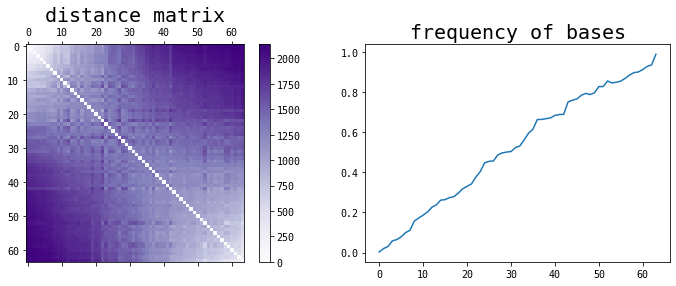

In [7]:
mask = mask_CT_TC
# mask = (base_freq_rel[:, 1] > 0.3) & (base_freq_rel[:, 3] > 0.3)

sorter = np.argsort(base_freq[mask, 3])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
# plt.gca().matshow(dist_mat[mask][:, mask][sorter][:, sorter])
plt.colorbar(
    plt.gca().matshow(dist_f[mask][:, mask][sorter][:, sorter], cmap='Purples')
)
plt.title('distance matrix', fontsize=20)

plt.subplot(1, 2, 2)
plt.gca().plot(base_freq_rel[mask_CT_TC, 3][sorter])
plt.title('frequency of bases', fontsize=20)

plt.show(); plt.close()

여러 시각화 방법을 동원한다 첫째로 차원 감소를 탐구합니다.

c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\umap\umap_.py:1780: UserWarning:

using precomputed metric; inverse_transform will be unavailable



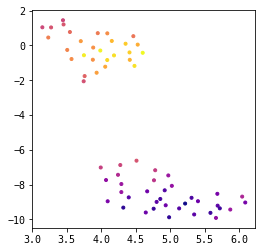

In [8]:
from umap import UMAP
# from sklearn.cluster import KMeans

umap = UMAP(
    random_state=42,
    metric='precomputed'
)
mask = mask_CT_TC
# mask = (base_freq_rel[:, 1] > 0.1) & (base_freq_rel[:, 3] > 0.1)
reduced = umap.fit_transform(dist_f[mask][:, mask])
# k_means = KMeans(n_clusters=4)
# k_means.fit(reduced)

plt.figure(figsize=(4, 4))
plt.scatter(
    *reduced.T, 
    s=9.,
    c=base_freq[mask, 3],
    cmap='plasma_r'
)
plt.show(); plt.close()

그러나 *mapper*가 보여주는 풍경은 사뭇 다릅니다.

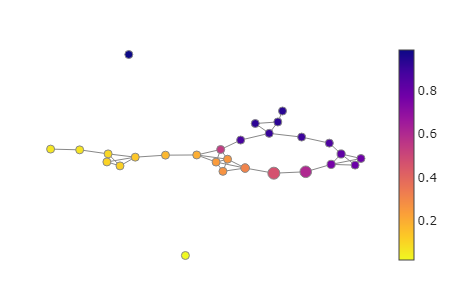

In [9]:
from gtda.mapper import CubicalCover, Projection, Eccentricity, Entropy, make_mapper_pipeline, plot_static_mapper_graph
from sklearn.cluster import DBSCAN
from sklearn.pipeline import make_union

mask = mask_CT_TC

pipe = make_mapper_pipeline(
    filter_func=make_union(
        Eccentricity(
            exponent=2,
            metric='precomputed'
        ),
        Entropy(),
    ),
    cover=CubicalCover(n_intervals=7, overlap_frac=0.28),
    clusterer=DBSCAN(
        metric='precomputed'
    ),
)
fig = plot_static_mapper_graph(
    pipe, 
    dist_f[mask][:, mask],
    color_data=base_freq_rel[mask, 3],
    plotly_params={'node_trace': {'marker_colorscale': 'plasma_r'}}
)
fig.show(renderer='png', width=450, height=300)
fig.close()

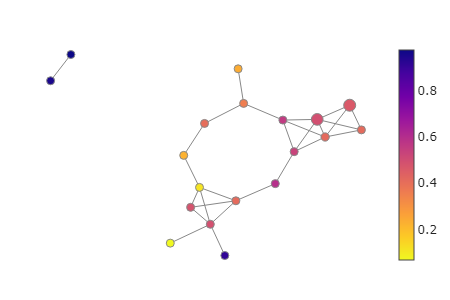

In [10]:
mask = mask_AG_GA

pipe = make_mapper_pipeline(
    filter_func=make_union(
        Eccentricity(
            exponent=2,
            metric='precomputed'
        ),
        Entropy(),
    ),
    cover=CubicalCover(n_intervals=6, overlap_frac=0.3),
    clusterer=DBSCAN(
        metric='precomputed'
    ),
)
fig = plot_static_mapper_graph(
    pipe, 
    dist_f[mask][:, mask],
    color_data=base_freq_rel[mask, 0],
    plotly_params={'node_trace': {'marker_colorscale': 'plasma_r'}}
)
fig.show(renderer='png', width=450, height=300)
fig.close()

In [81]:
from sklearn.model_selection import StratifiedKFold

splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X, y = df.iloc[:, 3:].values, df['Geographic region'].values
dist_f_trains = []
for num, (train_idxs, test_idxs) in enumerate(splitter.split(X, y)):
    dist_f_train = np.zeros((fd.shape[0], fd.shape[0]))
    for i, j in itertools.combinations(range(fd.shape[0]), 2):
        dist_f_train[i, j] = (fd.iloc[i] != fd.iloc[j])[train_idxs].mean()
        dist_f_train[j, i] = dist_f_train[i, j]
    dist_f_trains.append(dist_f_train)

In [180]:
mask = mask_CT_TC

pipe = make_mapper_pipeline(
    filter_func=make_union(
        Eccentricity(
            exponent=2,
            metric='precomputed'
        ),
        Entropy(),
    ),
    # cover=CubicalCover(n_intervals=7, overlap_frac=0.39),
    cover=CubicalCover(n_intervals=7, overlap_frac=0.28),
    clusterer=DBSCAN(
        metric='precomputed'
    ),
)

graph = pipe.fit_transform(dist_f[mask][:, mask]).to_networkx()
fig = plot_static_mapper_graph(
    pipe, 
    dist_f[mask][:, mask],
    color_data=base_freq_rel[mask, 1],
    plotly_params={'node_trace': {'marker_colorscale': 'plasma_r'}}
)
fig.show()
# fig.show(renderer='png', width=300, height=200)
fig.close()

In [ ]:
def node_members(graph, node):
    return graph.nodes[node]['node_elements']

# nodewise_members = [node_members(graphs[0], n) for n in graphs[0].nodes]
for n in graph.nodes:
    # print(n, node_members(graph, n))
    pass

for n, m in graph.edges:
    graph.edges[(n, m)]['edge_elements'] = sorted(set(node_members(graph, n)) & set(node_members(graph, m)))
    print((n, m), graph.edges[(n, m)]['edge_elements'])

In [194]:
for n, m in [(17, 26), (20, 26), (17, 22), (5, 22), (4, 5), (0, 4), (0, 19), (6, 19), (6, 7)]:
    print(graph.edges[(n ,m)]['edge_elements'])

[46]
[60]
[22]
[40]
[19, 30]
[10, 33]
[48]
[18, 21, 24, 36, 37]
[4, 11, 38, 39]


In [195]:
import networkx as nx

topo_irrel_ct = sorted([
    5, 6, 7, 26, 27, 29, 41, 45, 52, # purple tail
    1, # yelow hand
])
topo_rel_ct = sorted([
    4, 10, 11, 18, 21, 22, 24, 38
])

In [196]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = OrdinalEncoder().fit_transform(df.iloc[:, 3:].values)

splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splitted_idxs = list(splitter.split(X, y))
min_categories = df.iloc[:, 3:].nunique().values

topo_irrel_loci = np.where(mask_CT_TC)[0][topo_irrel_ct]
topo_rel_loci = np.where(mask_CT_TC)[0][topo_rel_ct]
for foo in [0, 1, 2, 3, 4, 5]:
    if foo == 2:
        X = np.delete(
            OrdinalEncoder().fit_transform(df.iloc[:, 3:].values), 
            topo_irrel_loci, 
        axis=1)
        min_categories = np.delete(
            df.iloc[:, 3:].nunique().values,
            topo_irrel_loci, axis=0)
        print()
        print('now we remove marginal')
        print()
    elif foo == 4:
        X = np.delete(
            OrdinalEncoder().fit_transform(df.iloc[:, 3:].values), 
            topo_rel_loci, 
        axis=1)
        min_categories = np.delete(
            df.iloc[:, 3:].nunique().values, 
            topo_rel_loci, axis=0)
        print()
        print('now we cut ring')
        print()

    if foo % 2 == 0:
        model = make_pipeline(
            # OrdinalEncoder(),
            CategoricalNB(
                alpha=1,
                min_categories=min_categories
            )
        )
    elif foo % 2 == 1:
        model = make_pipeline(
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    print(f'trial #{foo+1}, model={type(model[-1])}')

    acc_trains = np.empty((5, ))
    acc_tests = np.empty((5, ))
    for num, (train_idxs, test_idxs) in enumerate(splitted_idxs):
        X_train, X_test = X[train_idxs], X[test_idxs]
        y_train, y_test = y[train_idxs], y[test_idxs]
        model.fit(X_train, y_train)

        acc_trains[num] = 1e2*accuracy_score(y_train, model.predict(X_train))
        acc_tests[num] = 1e2*accuracy_score(y_test, model.predict(X_test))
        print(f'Fold #{num+1}',
            f'{acc_trains[num]:.2f}%',
            f'{acc_tests[num]:.2f}%'
        )
    print(f'{np.mean(acc_tests):.2f}%')

trial #1, model=<class 'sklearn.naive_bayes.CategoricalNB'>
Fold #1 90.36% 88.79%
Fold #2 90.94% 87.15%
Fold #3 89.83% 89.95%
Fold #4 89.89% 89.49%
Fold #5 91.00% 86.89%
88.45%
trial #2, model=<class 'sklearn.linear_model._logistic.LogisticRegression'>
Fold #1 96.55% 84.58%
Fold #2 96.73% 83.88%
Fold #3 96.43% 87.38%
Fold #4 97.08% 84.58%
Fold #5 97.55% 83.61%
84.81%

now we remove marginal

trial #3, model=<class 'sklearn.naive_bayes.CategoricalNB'>
Fold #1 90.24% 88.55%
Fold #2 90.77% 86.92%
Fold #3 89.54% 91.36%
Fold #4 90.12% 88.55%
Fold #5 90.48% 87.12%
88.50%
trial #4, model=<class 'sklearn.linear_model._logistic.LogisticRegression'>
Fold #1 96.14% 84.58%
Fold #2 96.08% 84.11%
Fold #3 95.79% 87.62%
Fold #4 96.32% 85.98%
Fold #5 96.85% 82.44%
84.95%

now we cut ring

trial #5, model=<class 'sklearn.naive_bayes.CategoricalNB'>
Fold #1 90.36% 88.55%
Fold #2 90.53% 86.21%
Fold #3 90.06% 89.49%
Fold #4 90.01% 88.79%
Fold #5 90.60% 87.12%
88.03%
trial #6, model=<class 'sklearn.linear_m

In [176]:
for n in marginal_loci:
    print(f'{n:0>3}', f'{1e2*max(base_freq_rel[n]):.2f}')
print()
for n in ring_loci:
    print(f'{n:0>3}', f'{1e2*max(base_freq_rel[n]):.2f}')

007 93.53
023 94.13
025 90.02
027 88.87
030 79.34
054 92.75
081 79.72
082 84.27
085 81.32
107 82.74
115 93.50
137 92.12

054 92.75
069 91.21
069 91.21
104 88.48
116 89.71
135 90.02
159 85.53


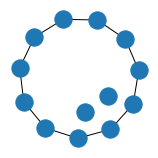

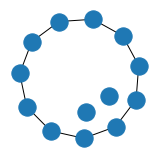

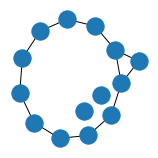

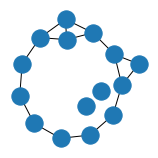

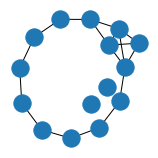

In [172]:
import networkx as nx
import itertools

marginal_loci_ct = sorted([
    1, 16, # yellow tail
    5, 6, 7, 26, 27, 29, 41, 45, 52, # purple leg
    9, # orange ear
])

ring_loci_ct = sorted([
    22, 40, # between tail and ear
    60, # between leg and tail
    16, 22, 46, 51, # between them
])

for graph in graphs:
    g = nx.Graph()
    lookup = []
    for n in graph.nodes:
        removed = set(filter(
            lambda el: el not in marginal_loci_ct, graph.nodes[n]['node_elements']
        ))
        if not removed:
            continue
        if any(removed.issubset(el) for el in lookup):
            continue
        lookup.append(removed)
        g.add_node(n)
        g.nodes[n]['node_elements'] = removed
    for n, m in itertools.combinations(g.nodes, 2):
        if set(g.nodes[n]['node_elements']) & set(g.nodes[m]['node_elements']):
            g.add_edge(n, m)
    plt.figure(figsize=(2, 2))
    nx.draw_kamada_kawai(g)
    plt.show()
    plt.close()

In [174]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = OrdinalEncoder().fit_transform(df.iloc[:, 3:].values)

splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splitted_idxs = list(splitter.split(X, y))
min_categories = df.iloc[:, 3:].nunique().values
# model = make_pipeline(
#     # OrdinalEncoder(),
#     CategoricalNB(
#         alpha=1,
#         min_categories=df.iloc[:, 3:].nunique()
#     )
# )

marginal_loci = np.where(mask_CT_TC)[0][marginal_loci_ct]
ring_loci = np.where(mask_CT_TC)[0][ring_loci_ct]
for foo in [0, 1, 2, 3, 4, 5]:
    if foo == 2:
        X = np.delete(
            OrdinalEncoder().fit_transform(df.iloc[:, 3:].values), 
            marginal_loci, 
        axis=1)
        min_categories = np.delete(
            df.iloc[:, 3:].nunique().values,
        marginal_loci, axis=0)
        print()
        print('now we remove marginal')
        print()
    elif foo == 4:
        X = np.delete(
            OrdinalEncoder().fit_transform(df.iloc[:, 3:].values), 
            ring_loci, 
        axis=1)
        min_categories = np.delete(
            df.iloc[:, 3:].nunique().values, 
            ring_loci, axis=0)
        print()
        print('now we cut ring')
        print()

    if foo % 2 == 0:
        model = make_pipeline(
            # OrdinalEncoder(),
            CategoricalNB(
                alpha=1,
                min_categories=min_categories
            )
        )
    elif foo % 2 == 1:
        model = make_pipeline(
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    print(f'trial #{foo+1}, model={type(model[-1])}')

    acc_trains = np.empty((5, ))
    acc_tests = np.empty((5, ))
    for num, (train_idxs, test_idxs) in enumerate(splitted_idxs):
        X_train, X_test = X[train_idxs], X[test_idxs]
        y_train, y_test = y[train_idxs], y[test_idxs]
        model.fit(X_train, y_train)

        acc_trains[num] = 1e2*accuracy_score(y_train, model.predict(X_train))
        acc_tests[num] = 1e2*accuracy_score(y_test, model.predict(X_test))
        print(f'Fold #{num+1}',
            f'{acc_trains[num]:.2f}%',
            f'{acc_tests[num]:.2f}%'
        )
    print(f'{np.mean(acc_tests):.2f}%')

trial #1, model=<class 'sklearn.naive_bayes.CategoricalNB'>
Fold #1 90.36% 88.79%
Fold #2 90.94% 87.15%
Fold #3 89.83% 89.95%
Fold #4 89.89% 89.49%
Fold #5 91.00% 86.89%
88.45%
trial #2, model=<class 'sklearn.linear_model._logistic.LogisticRegression'>
Fold #1 96.55% 84.58%
Fold #2 96.73% 83.88%
Fold #3 96.43% 87.38%
Fold #4 97.08% 84.58%
Fold #5 97.55% 83.61%
84.81%

now we remove marginal

trial #3, model=<class 'sklearn.naive_bayes.CategoricalNB'>
Fold #1 90.01% 89.25%
Fold #2 90.59% 87.38%
Fold #3 89.48% 91.12%
Fold #4 90.01% 88.08%
Fold #5 90.60% 86.42%
88.45%
trial #4, model=<class 'sklearn.linear_model._logistic.LogisticRegression'>
Fold #1 95.50% 85.05%
Fold #2 96.03% 83.64%
Fold #3 95.56% 87.85%
Fold #4 96.43% 85.75%
Fold #5 96.44% 82.90%
85.04%

now we cut ring

trial #5, model=<class 'sklearn.naive_bayes.CategoricalNB'>
Fold #1 89.83% 89.49%
Fold #2 90.53% 86.45%
Fold #3 89.36% 89.02%
Fold #4 89.60% 88.08%
Fold #5 90.83% 85.95%
87.80%
trial #6, model=<class 'sklearn.linear_m